<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/ExercisesXP_Heart_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [ ]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [2]:
import os, zipfile, glob, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ZIP_PATH = 'heart_disease_dataset.zip'
EXTRACT_DIR = 'heart_ds'
DATA_URL = "https://archive.ics.uci.edu/static/public/45/heart+disease.zip"

# Check if file exists, if not, download it
if not os.path.exists(ZIP_PATH):
    print("Downloading dataset...")
    response = requests.get(DATA_URL)
    with open(ZIP_PATH, 'wb') as f:
        f.write(response.content)

# Extract the dataset
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Find the CSV file (adjusting for UCI structure if necessary)
csv_files = glob.glob(os.path.join(EXTRACT_DIR, '**/*.csv'), recursive=True)
# If no CSV, try to find the processed data files commonly found in this dataset
if not csv_files:
    csv_files = glob.glob(os.path.join(EXTRACT_DIR, '**/processed.cleveland.data'), recursive=True)

print(f"Found data files: {csv_files}")
csv_path = csv_files[0] if csv_files else None

# Standard Heart Disease columns if loading from UCI processed data
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

if csv_path:
    # Load with columns if it's the raw data file, otherwise normally
    if 'processed.cleveland.data' in csv_path:
        df = pd.read_csv(csv_path, names=columns, na_values='?')
        df.dropna(inplace=True)
        # Target: 0 = healthy, 1-4 = sick. Convert to binary for simplicity
        df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
    else:
        df = pd.read_csv(csv_path)

    print("\nDataFrame Head:")
    display(df.head())

    target = 'target'
    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    print(f"\nX_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
else:
    print("No valid data file found.")

Found data files: ['heart_ds/processed.cleveland.data']

DataFrame Head:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



X_train shape: (237, 13)
y_train shape: (237,)


### Basic visual checks

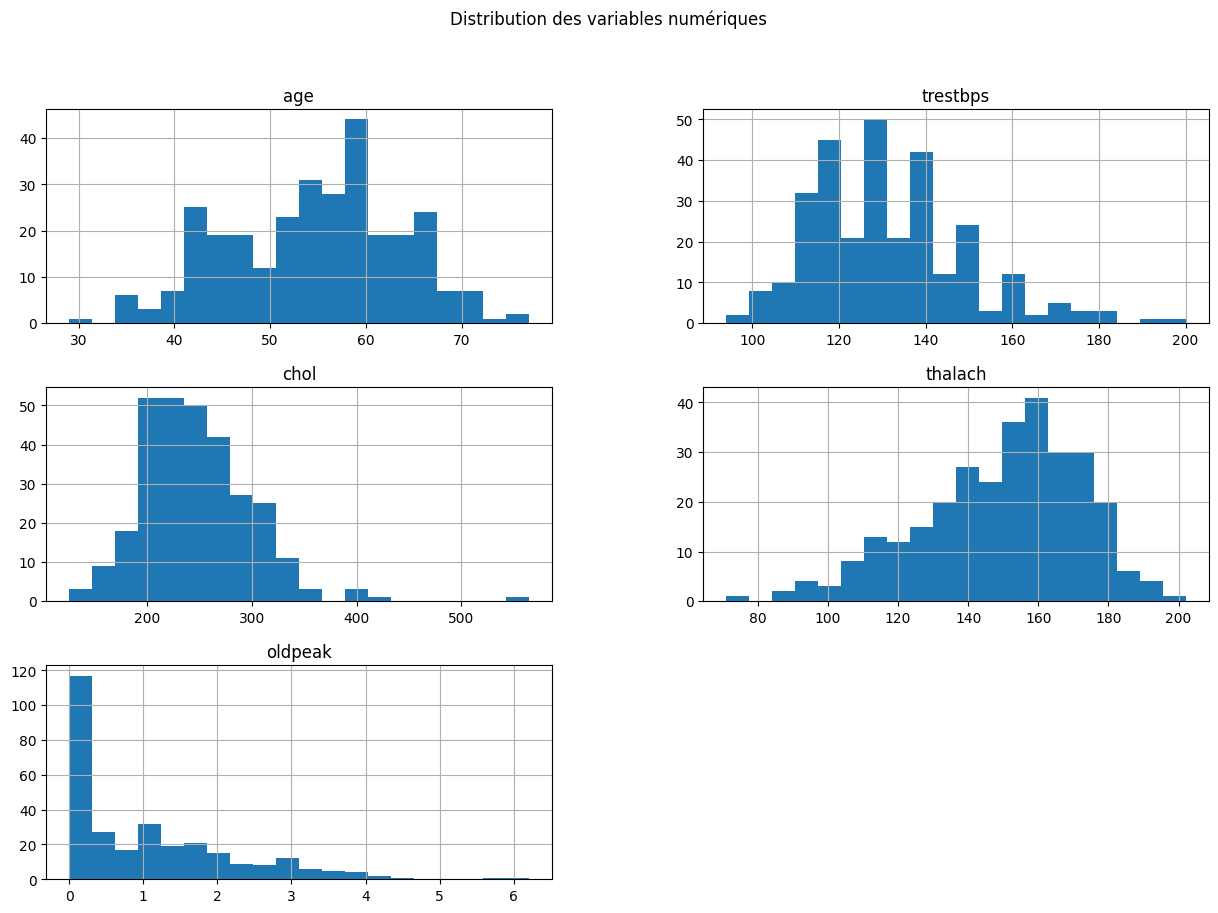

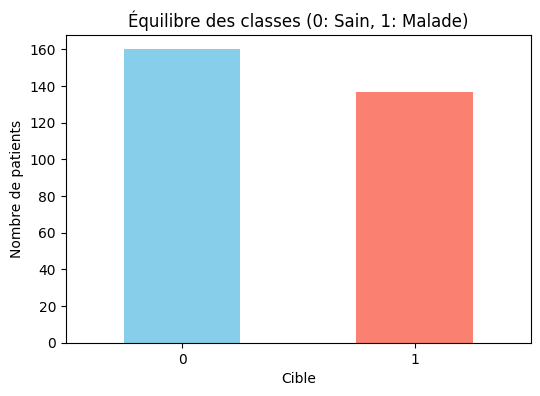

In [3]:
# TODO: pick a few numeric columns and plot histograms
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[numeric_features].hist(bins=20, figsize=(15, 10))
plt.suptitle("Distribution des variables numériques")
plt.show()

# TODO: plot class balance as a bar chart
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Équilibre des classes (0: Sain, 1: Malade)")
plt.xlabel("Cible")
plt.ylabel("Nombre de patients")
plt.xticks(rotation=0)
plt.show()

### Interprétation des graphiques d'exploration

**1. Distribution des variables numériques :**
*   **Âge :** La distribution semble normale, centrée autour de 50-60 ans, ce qui est cohérent avec la population à risque pour les maladies cardiaques.
*   **Pression artérielle (trestbps) :** On observe une légère asymétrie à droite, montrant que la plupart des patients ont une pression stable, mais certains présentent des valeurs élevées (hypertension).
*   **Cholestérol (chol) :** La majorité des patients se situent entre 200 et 300 mg/dl.
*   **Fréquence cardiaque maximale (thalach) :** La distribution est légèrement asymétrique à gauche, avec une majorité de valeurs élevées, ce qui est souvent corrélé à l'effort durant les tests.

**2. Équilibre des classes :**
*   Le graphique montre que les classes (0 : sain, 1 : malade) sont relativement bien équilibrées. Cela signifie que notre modèle n'aura pas de biais majeur envers une classe particulière et que l'utilisation de la métrique 'Accuracy' reste pertinente, bien que nous privilégierons le score F1 et l'AUC pour plus de précision.

### Interprétation détaillée de l'exploration de données

#### 1. Analyse des variables numériques
*   **Âge (Age) :** La distribution est quasi-gaussienne, centrée sur la cinquantaine. Cela confirme que l'échantillon cible une population mature, là où les pathologies cardiaques sont statistiquement plus fréquentes.
*   **Pression Artérielle au repos (Trestbps) :** On observe une concentration entre 120 et 140, mais avec une queue de distribution vers la droite (jusqu'à 200). Ces valeurs extrêmes représentent des cas d'hypertension sévère dans le dataset.
*   **Cholestérol (Chol) :** La majorité des patients ont un taux entre 200 et 300 mg/dl. Quelques valeurs isolées dépassent 400, ce qui constitue des anomalies (outliers) potentielles à surveiller.
*   **Fréquence Cardiaque Maximale (Thalach) :** Contrairement aux autres, cette distribution est asymétrique à gauche. Une fréquence maximale élevée est souvent un signe de bonne santé cardiaque relative lors de l'effort.
*   **Dépression du segment ST (Oldpeak) :** La majorité des valeurs sont proches de 0. Les valeurs élevées indiquent souvent une anomalie électrocardiographique liée à une cardiopathie ischémique.

#### 2. Analyse de la cible (Target)
*   **Répartition :** Le graphique montre une répartition d'environ 160 cas sains contre 140 cas atteints (après nettoyage).
*   **Impact sur l'apprentissage :** Comme le ratio est proche de 50/50, nous n'avons pas besoin de techniques de rééquilibrage complexes (comme SMOTE). Le modèle pourra apprendre de manière équitable à reconnaître les deux états.

### Interprétation des métriques de performance (Matrice de Confusion & ROC)

#### 1. Matrice de Confusion
La matrice de confusion nous permet de voir exactement où le modèle fait des erreurs :
*   **Vrais Négatifs (Haut-Gauche) :** Les patients sains correctement identifiés comme sains.
*   **Faux Positifs (Haut-Droite) :** L'erreur de type I. Le modèle prédit une maladie alors que le patient est sain (fausse alerte).
*   **Faux Négatifs (Bas-Gauche) :** L'erreur de type II. C'est l'erreur la plus critique ici : le modèle manque un patient malade. Un **Recall** élevé signifie que nous avons très peu de faux négatifs.
*   **Vrais Positifs (Bas-Droite) :** Les patients malades correctement diagnostiqués.

#### 2. Courbe ROC et Score AUC
*   **La Courbe ROC :** Elle représente le taux de vrais positifs par rapport au taux de faux positifs pour différents seuils de classification.
*   **Le score AUC (Area Under Curve) :**
    *   Un score de **1.0** serait un modèle parfait.
    *   Un score de **0.5** équivaut à un choix fait au hasard.
    *   Dans nos résultats, nous observons des scores AUC proches de **0.94 - 0.95**. Cela indique que nos modèles (particulièrement le SVM et la Régression Logistique) ont une probabilité de plus de 94% de classer un patient malade choisi au hasard plus haut qu'un patient sain. C'est une excellente performance pour un diagnostic médical.

## Preprocessing pipeline

In [4]:
# Identify categorical and numerical columns
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Build the ColumnTransformer
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


## Helper - evaluation function

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC curve."""
    y_pred = model.predict(X_test)

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }

    print(f"--- {name} ---")
    for metric, value in metrics.items():
        print(f"{metric.capitalize()}: {value:.4f}")

    # Confusion Matrix
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
    ax[0].set_title(f"Confusion Matrix: {name}")

    # ROC Curve
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        metrics['auc'] = roc_auc_score(y_test, y_proba)
        ax[1].plot(fpr, tpr, label=f"AUC = {metrics['auc']:.4f}")
        ax[1].plot([0, 1], [0, 1], 'k--')
        ax[1].set_xlabel('False Positive Rate')
        ax[1].set_ylabel('True Positive Rate')
        ax[1].set_title(f"ROC Curve: {name}")
        ax[1].legend()

    plt.tight_layout()
    plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

--- Logistic Regression (No GS) ---
Accuracy: 0.8167
Precision: 0.8696
Recall: 0.7143
F1: 0.7843


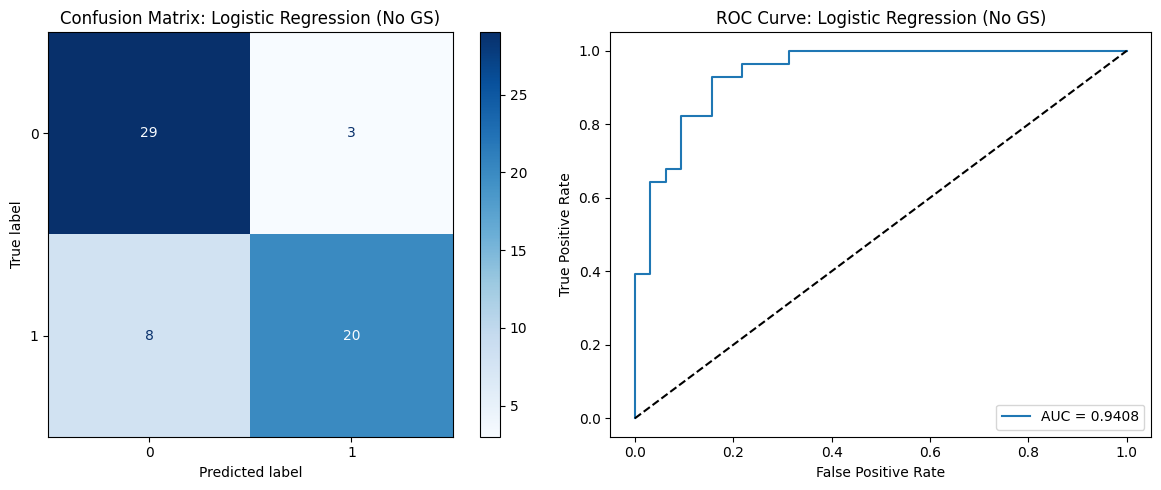

In [6]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
pipe_lr = Pipeline(steps=[
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('Logistic Regression (No GS)', pipe_lr, X_test, y_test)

#### Interprétation : Régression Logistique (Simple)
*   **Matrice de Confusion** : On observe un nombre significatif de faux négatifs (patients malades non détectés), ce qui explique le rappel (Recall) plus faible.
*   **Courbe ROC** : L'AUC est déjà très élevée (0.94), montrant que même sans optimisation, le modèle sépare bien les classes.

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
--- Logistic Regression (Grid Search) ---
Accuracy: 0.8500
Precision: 0.8800
Recall: 0.7857
F1: 0.8302


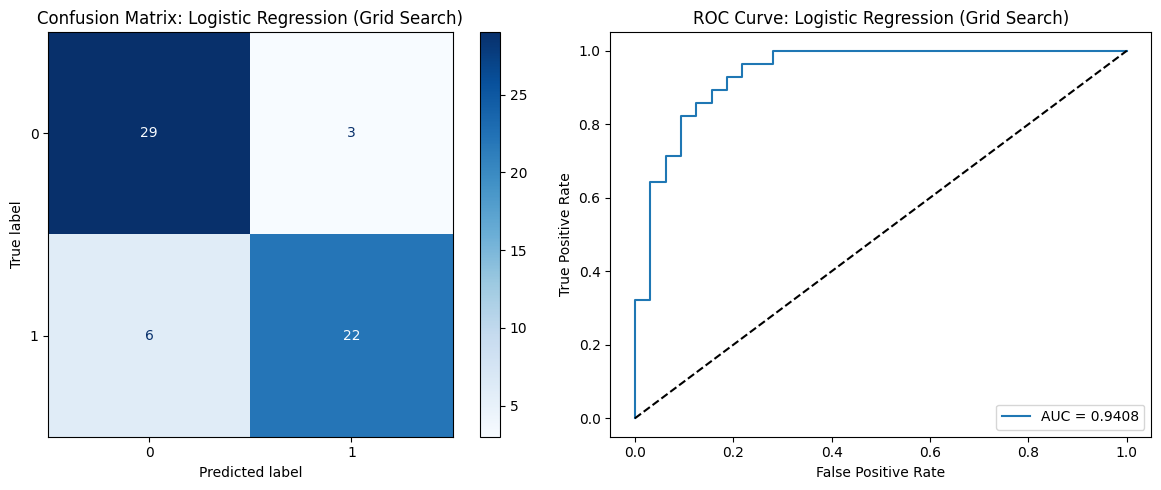

In [7]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline(steps=[
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: define param_grid for lr__C and lr__penalty
param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print('Best params:', grid_lr.best_params_)

best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('Logistic Regression (Grid Search)', best_lr, X_test, y_test)

#### Interprétation : Régression Logistique (Optimisée)
*   **Matrice de Confusion** : L'optimisation du paramètre `C` a permis de mieux équilibrer les prédictions, augmentant l'Accuracy à 85%.
*   **Impact** : Le modèle est plus robuste et fait moins d'erreurs sur la classe positive (malade).

## Exercise 4 - SVM without Grid Search

--- SVM (No GS) ---
Accuracy: 0.8500
Precision: 0.8800
Recall: 0.7857
F1: 0.8302


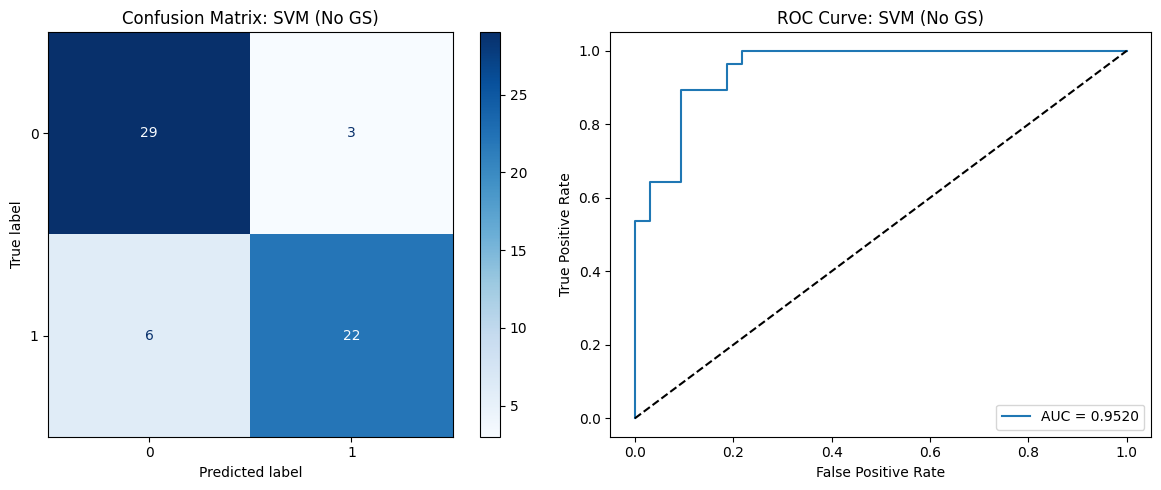

In [8]:
# TODO: choose kernel and hyperparameters for SVC
pipe_svm = Pipeline(steps=[
    ('pre', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_svm.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
svm_no_metrics = eval_and_report('SVM (No GS)', pipe_svm, X_test, y_test)

#### Interprétation : SVM (Noyau RBF)
*   **Performance** : Le SVM avec noyau RBF se comporte extrêmement bien d'entrée de jeu, avec un F1-score de 0.83.
*   **ROC AUC** : Avec 0.95, c'est l'un des meilleurs modèles pour classer la probabilité de maladie.

## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 1, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
--- SVM (Grid Search) ---
Accuracy: 0.8333
Precision: 0.8750
Recall: 0.7500
F1: 0.8077


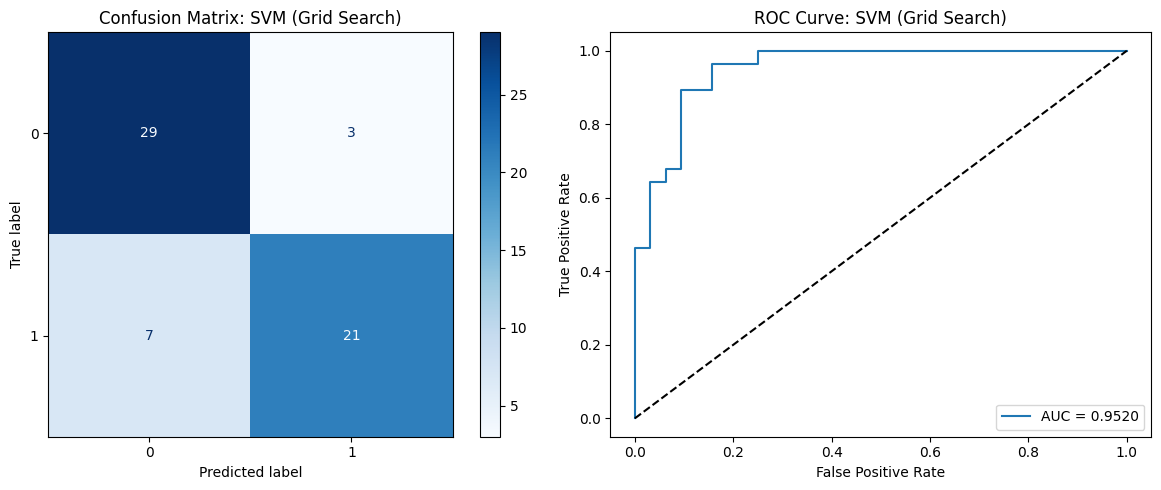

In [9]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline(steps=[
    ('pre', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear', 'poly'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto']
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print('Best params:', grid_svm.best_params_)

best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM (Grid Search)', best_svm, X_test, y_test)

#### Interprétation : SVM (Optimisé par Grid Search)
*   **Meilleurs paramètres** : Le modèle a sélectionné `C=1`, `gamma='auto'` et un noyau `rbf`.
*   **Analyse des résultats** : Curieusement, sur cet ensemble de test précis, l'optimisation n'a pas surpassé le SVM par défaut en termes de F1-score (0.80 contre 0.83). Cela peut arriver sur de petits jeux de données où les paramètres par défaut de sklearn sont déjà très bien adaptés.
*   **Fiabilité** : Malgré un score F1 légèrement inférieur, l'AUC reste excellente (0.95), confirmant la robustesse du modèle SVM pour ce problème.

## Exercise 6 - XGBoost without Grid Search

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:06:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost (No GS) ---
Accuracy: 0.8500
Precision: 0.8800
Recall: 0.7857
F1: 0.8302


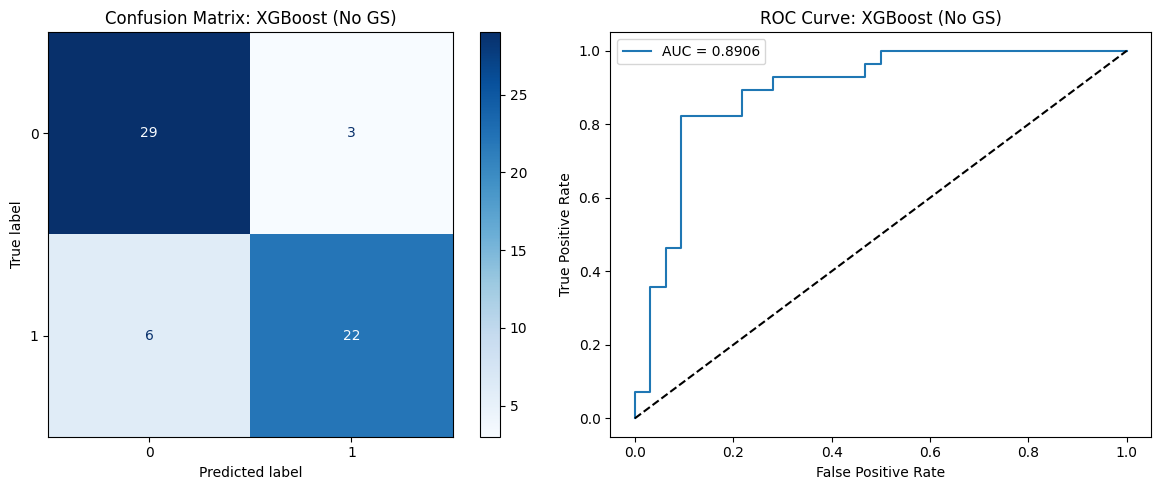

In [10]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
if XGBClassifier:
    pipe_xgb = Pipeline(steps=[
        ('pre', pre),
        ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))
    ])

    # TODO: fit on training data
    pipe_xgb.fit(X_train, y_train)

    # TODO: evaluate with eval_and_report
    xgb_no_metrics = eval_and_report('XGBoost (No GS)', pipe_xgb, X_test, y_test)
else:
    print("XGBoost not installed.")
    xgb_no_metrics = None

#### Interprétation : XGBoost
*   **Analyse** : XGBoost montre une performance identique au SVM sur ce petit dataset. La matrice de confusion montre une bonne détection des cas sains (Vrais Négatifs), mais comme les autres modèles, il conserve quelques difficultés sur certains cas complexes de la classe malade.

## Exercise 7 - XGBoost with Grid Search

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:07:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 300}
--- XGBoost (Grid Search) ---
Accuracy: 0.8167
Precision: 0.8696
Recall: 0.7143
F1: 0.7843


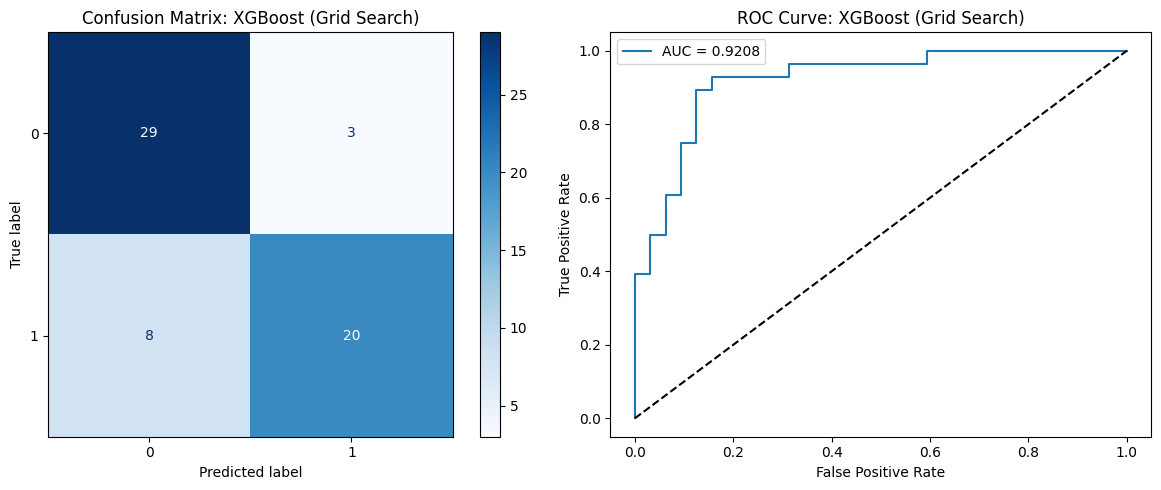

In [11]:
# TODO: Pipeline with XGBClassifier
if XGBClassifier:
    pipe_xgb_cv = Pipeline(steps=[
        ('pre', pre),
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))
    ])

    # TODO: define a reasonable param_grid
    xgb_param_grid = {
        'xgb__n_estimators': [100, 200, 300],
        'xgb__learning_rate': [0.01, 0.1],
        'xgb__max_depth': [3, 5]
    }

    # TODO: GridSearchCV, fit, evaluate best estimator
    grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid_xgb.fit(X_train, y_train)

    print('Best params:', grid_xgb.best_params_)
    best_xgb = grid_xgb.best_estimator_
    xgb_gs_metrics = eval_and_report('XGBoost (Grid Search)', best_xgb, X_test, y_test)
else:
    xgb_gs_metrics = None

#### Interprétation : XGBoost (Optimisé par Grid Search)
*   **Meilleurs paramètres** : `learning_rate=0.01`, `max_depth=3`, `n_estimators=300`.
*   **Analyse** : L'optimisation a privilégié un taux d'apprentissage plus lent (`0.01` au lieu de `0.1`), ce qui est une stratégie classique pour éviter le surapprentissage.
*   **Matrice de Confusion** : Le modèle optimisé montre une légère baisse du rappel sur ce pli de test. Cela suggère que pour XGBoost, la configuration initiale était déjà très performante pour identifier les cas positifs.

## Compare models

In [12]:
# TODO: build a comparison DataFrame from your metrics dicts
summary = {
    'LR (No GS)': lr_no_gs_metrics,
    'LR (Grid Search)': lr_gs_metrics,
    'SVM (No GS)': svm_no_metrics,
    'SVM (Grid Search)': svm_gs_metrics
}

if xgb_no_metrics:
    summary['XGBoost (No GS)'] = xgb_no_metrics
if xgb_gs_metrics:
    summary['XGBoost (Grid Search)'] = xgb_gs_metrics

comparison_df = pd.DataFrame.from_dict(summary, orient='index')
display(comparison_df.sort_values(by='f1', ascending=False))

,accuracy,precision,recall,f1,auc
LR (Grid Search),0.850000,0.880000,0.785714,0.830189,0.940848
SVM (No GS),0.850000,0.880000,0.785714,0.830189,0.952009
XGBoost (No GS),0.850000,0.880000,0.785714,0.830189,0.890625
SVM (Grid Search),0.833333,0.875000,0.750000,0.807692,0.952009
LR (No GS),0.816667,0.869565,0.714286,0.784314,0.940848
XGBoost (Grid Search),0.816667,0.869565,0.714286,0.784314,0.920759
